# ADL Lab 3 - Group 5

### Task 3.1.1
Explain the pros and cons of utilising Concatenation for combining embeddings.

- Pros: It preserves all information from both vectors without overwriting any features.
- Cons: It increases the input size for the next layer, which adds more parameters and computational weight.

### Task 3.1.2
Explain the pros and cons of utilising Addition
for combining embeddings.

- Pros: It keeps the vector size constant, saving memory.
- Cons: It requires both vectors to be exactly the same size and can "muddy" the distinct information from the image and text.

### Task 3.1.3
Explain the pros and cons of utilising Multiplication for combining embeddings.

- Pros: Acts as a powerful "gate" where image features can scale the importance of certain words.
- Cons: If one vector has many values near zero, it can effectively "kill" the signal from the other vector.

### Task 3.1.4
Explain the pros and cons of utilising Attention for combining embeddings.

- Pros: Allows the model to focus on specific regions of the image for specific words.
- Cons: Much more complex to implement and mathematically expensive.

### Task 3.1.5
Explain the pros and cons of utilising Difference for combining embeddings.

- Pros: Keeps the vector size constant for memory efficiency and can highlight "residual" features that the model hasn't yet described.
- Cons: High risk of signal cancellation if embeddings are similar and is sensitive to the order of subtraction (non-commutative).

## Task 3.2

In [ ]:
!unzip -q /content/archive.zip -d /content/dataset/

In [ ]:
import sys
import os
import site

# 1. Use %pip (magic command) to install specifically for this kernel
%pip install --user torch torchvision torchaudio nltk matplotlib pandas Pillow tqdm

# 2. Tell Python exactly where to look for the newly installed packages
user_site = site.getusersitepackages()
if user_site not in sys.path:
    sys.path.append(user_site)

# 3. Now try the imports
import nltk
import torch

# 4. Download necessary data
nltk.download('punkt')

print(f"\nSuccess! Torch version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

Success! Torch version: 2.11.0+cu130
CUDA Available: True


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### Imports and Device Configuration

In [ ]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import pandas as pd
import os
from collections import Counter
import json

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Safe Word Map Creation

In [ ]:
def create_word_map_safe(csv_path, min_word_freq=5):
    df = pd.read_csv(csv_path)
    word_freq = Counter()
    for caption in df['caption']:
        # Basic cleaning: lowercase and remove punctuation
        clean_caption = str(caption).lower().replace('.', '').replace(',', '').split()
        word_freq.update(clean_caption)

    # Filter words by frequency
    frequent_words = [w for w, count in word_freq.items() if count >= min_word_freq]

    # Define word_map with special tokens at the start
    word_map = {'<pad>': 0, '<start>': 1, '<end>': 2, '<unk>': 3}
    for i, word in enumerate(frequent_words):
        word_map[word] = i + 4 # Indices start after the 4 special tokens

    return word_map

# Run and save the word map
caption_file = "/content/dataset/captions.txt"
word_map = create_word_map_safe(caption_file)
vocab_size = len(word_map)
print(f"Safe Vocabulary Size: {vocab_size}")

with open('word_map.json', 'w') as f:
    json.dump(word_map, f)

Safe Vocabulary Size: 3003


Dataset Class and DataLoader

In [ ]:
# Standard ImageNet transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class Flickr8kDataset(Dataset):
    def __init__(self, csv_path, img_dir, word_map, transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.word_map = word_map
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        img_name = self.df.iloc[i]['image']
        image = Image.open(os.path.join(self.img_dir, img_name)).convert('RGB')
        if self.transform:
            image = self.transform(image)

        caption = str(self.df.iloc[i]['caption']).lower().split()
        tokens = [self.word_map['<start>']] + \
                 [self.word_map.get(w, self.word_map['<unk>']) for w in caption] + \
                 [self.word_map['<end>']]

        # Pad captions to a fixed length of 40
        tokens = tokens[:40] + [self.word_map['<pad>']] * (40 - len(tokens))
        return image, torch.LongTensor(tokens)

# Initialize DataLoader
image_folder = "/content/dataset/Images"
dataset = Flickr8kDataset(caption_file, image_folder, word_map, transform=transform)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

Model Architecture (Encoder & Decoder)

In [ ]:
class Encoder(nn.Module):
    def __init__(self, embed_size):
        super(Encoder, self).__init__()
        resnet = models.resnet101(pretrained=True)
        for param in resnet.parameters():
            param.requires_grad = False
        self.resnet = nn.Sequential(*list(resnet.children())[:-2])
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(resnet.fc.in_features, embed_size)

    def forward(self, images):
        features = self.resnet(images)
        features = self.adaptive_pool(features).view(features.size(0), -1)
        return self.fc(features)

class Decoder(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size):
        super(Decoder, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.linear = nn.Linear(hidden_size, vocab_size)

    def forward(self, features, captions):
        embeddings = self.embed(captions[:, :-1])
        inputs = torch.cat((features.unsqueeze(1), embeddings), dim=1)
        hiddens, _ = self.lstm(inputs)
        return self.linear(hiddens)

Initialization

In [ ]:
embed_size = 256
hidden_size = 512

encoder = Encoder(embed_size).to(device)
decoder = Decoder(embed_size, hidden_size, vocab_size).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0).to(device)
optimizer = torch.optim.Adam(
    list(decoder.parameters()) + list(encoder.fc.parameters()),
    lr=1e-3
)

/root/.local/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/root/.local/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training

In [ ]:
# Check for specific important words
test_words = ['bike', 'motorcycle', 'bicycle', 'person', 'riding', 'water', 'soccer']

print("--- Vocabulary Check ---")
for word in test_words:
    exists = word in word_map
    index = word_map.get(word, "NOT FOUND")
    print(f"Word: '{word}' | In Word Map: {exists} | Index: {index}")

# Also check how many words are actually in dictionary
print(f"\nTotal Vocabulary Size: {len(word_map)}")

--- Vocabulary Check ---
Word: 'bike' | In Word Map: True | Index: 506
Word: 'motorcycle' | In Word Map: True | Index: 1086
Word: 'bicycle' | In Word Map: True | Index: 509
Word: 'person' | In Word Map: True | Index: 178
Word: 'riding' | In Word Map: True | Index: 592
Word: 'water' | In Word Map: True | Index: 135
Word: 'soccer' | In Word Map: True | Index: 703

Total Vocabulary Size: 3003


In [ ]:
%pip install --user --upgrade pyparsing matplotlib

import sys
import site
user_site = site.getusersitepackages()
if user_site not in sys.path:
    sys.path.insert(0, user_site) # Insert at index 0 for highest priority

print("Dependencies updated.")


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Dependencies updated.


Training (25 epochs)

In [ ]:
import torch
import os
import matplotlib.pyplot as plt

# Initialize or reset loss history
loss_history = []

def train_with_checkpoints(epochs=25):
    print(f"Starting fresh training on {device}...")

    for epoch in range(epochs):
        encoder.train()
        decoder.train()
        epoch_loss = 0

        for i, (images, captions) in enumerate(train_loader):
            images, captions = images.to(device), captions.to(device)

            # Forward pass
            features = encoder(images)
            outputs = decoder(features, captions)

            targets = captions[:, 1:]
            outputs = outputs[:, :-1, :]

            loss = criterion(outputs.reshape(-1, vocab_size), targets.reshape(-1))

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if i % 50 == 0:
                print(f"Epoch [{epoch+1}/{epochs}], Step [{i}/{len(train_loader)}], Loss: {loss.item():.4f}")

        # Calculate average epoch loss
        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"==> Epoch [{epoch+1}] Finished. Avg Loss: {avg_loss:.4f}")

        # SAVE PROGRESS: This saves the model to the Colab disk every epoch
        checkpoint = {
            'epoch': epoch + 1,
            'encoder_state_dict': encoder.state_dict(),
            'decoder_state_dict': decoder.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss_history': loss_history,
            'word_map': word_map
        }
        torch.save(checkpoint, "flickr8k_checkpoint.pth")
        print(f"Successfully saved checkpoint to flickr8k_checkpoint.pth\n")

# Run the 25-epoch training
train_with_checkpoints(epochs=25)

Starting fresh training on cuda...
Epoch [1/25], Step [0/1265], Loss: 8.0148
Epoch [1/25], Step [50/1265], Loss: 4.7530
Epoch [1/25], Step [100/1265], Loss: 4.7351
Epoch [1/25], Step [150/1265], Loss: 4.1905
Epoch [1/25], Step [200/1265], Loss: 3.9829
Epoch [1/25], Step [250/1265], Loss: 4.2935
Epoch [1/25], Step [300/1265], Loss: 4.0633
Epoch [1/25], Step [350/1265], Loss: 4.2316
Epoch [1/25], Step [400/1265], Loss: 4.0618
Epoch [1/25], Step [450/1265], Loss: 3.9008
Epoch [1/25], Step [500/1265], Loss: 4.0056
Epoch [1/25], Step [550/1265], Loss: 4.0725
Epoch [1/25], Step [600/1265], Loss: 3.7593
Epoch [1/25], Step [650/1265], Loss: 3.7469
Epoch [1/25], Step [700/1265], Loss: 3.9177
Epoch [1/25], Step [750/1265], Loss: 3.9113
Epoch [1/25], Step [800/1265], Loss: 3.5752
Epoch [1/25], Step [850/1265], Loss: 4.0237
Epoch [1/25], Step [900/1265], Loss: 3.7093
Epoch [1/25], Step [950/1265], Loss: 3.7464
Epoch [1/25], Step [1000/1265], Loss: 3.9265
Epoch [1/25], Step [1050/1265], Loss: 3.772

In [ ]:
Extra epochs

In [ ]:
def train_more(additional_epochs=5):
    # Identify where we left off
    start_epoch = len(loss_history) + 1
    total_target_epochs = len(loss_history) + additional_epochs

    print(f"Resuming training from Epoch {start_epoch} to reach {total_target_epochs} total epochs...")

    for epoch in range(additional_epochs):
        encoder.train()
        decoder.train()
        epoch_loss = 0

        current_display_epoch = start_epoch + epoch

        for i, (images, captions) in enumerate(train_loader):
            images, captions = images.to(device), captions.to(device)

            # Forward pass
            features = encoder(images)
            outputs = decoder(features, captions)

            # Prepare targets (predicting the next word)
            targets = captions[:, 1:]
            outputs = outputs[:, :-1, :]

            loss = criterion(outputs.reshape(-1, vocab_size), targets.reshape(-1))

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if i % 50 == 0:
                print(f"Epoch [{current_display_epoch}/{total_target_epochs}], "
                      f"Step [{i}/{len(train_loader)}], Current Loss: {loss.item():.4f}")

        # Calculate and record the average loss for this epoch
        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"==> Epoch [{current_display_epoch}] Finished. Avg Loss: {avg_loss:.4f}")

        # Update the existing checkpoint file on the ICE cluster
        checkpoint = {
            'epoch': current_display_epoch,
            'encoder_state_dict': encoder.state_dict(),
            'decoder_state_dict': decoder.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss_history': loss_history,
            'word_map': word_map
        }
        torch.save(checkpoint, "flickr8k_checkpoint.pth")
        print(f"Checkpoint updated at Epoch {current_display_epoch}.\n")

# Execute the final push to 30 epochs
train_more(additional_epochs=5)

Resuming training from Epoch 26 to reach 30 total epochs...
Epoch [26/30], Step [0/1265], Current Loss: 1.4158
Epoch [26/30], Step [50/1265], Current Loss: 1.4928
Epoch [26/30], Step [100/1265], Current Loss: 1.2845
Epoch [26/30], Step [150/1265], Current Loss: 1.3137
Epoch [26/30], Step [200/1265], Current Loss: 1.4418
Epoch [26/30], Step [250/1265], Current Loss: 1.2993
Epoch [26/30], Step [300/1265], Current Loss: 1.3417
Epoch [26/30], Step [350/1265], Current Loss: 1.3757
Epoch [26/30], Step [400/1265], Current Loss: 1.4441
Epoch [26/30], Step [450/1265], Current Loss: 1.4115
Epoch [26/30], Step [500/1265], Current Loss: 1.4152
Epoch [26/30], Step [550/1265], Current Loss: 1.3754
Epoch [26/30], Step [600/1265], Current Loss: 1.3283
Epoch [26/30], Step [650/1265], Current Loss: 1.4708
Epoch [26/30], Step [700/1265], Current Loss: 1.3964
Epoch [26/30], Step [750/1265], Current Loss: 1.5590
Epoch [26/30], Step [800/1265], Current Loss: 1.5654
Epoch [26/30], Step [850/1265], Current Lo

Visualization

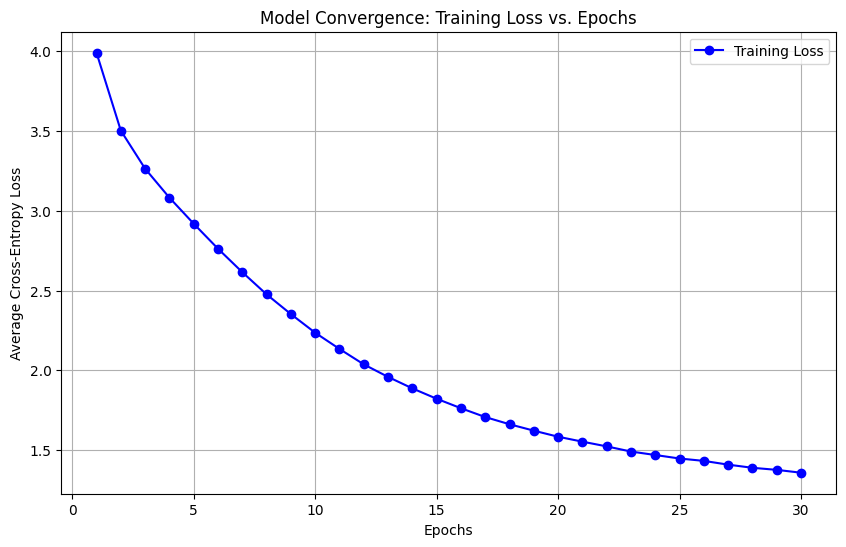

In [ ]:
# Create the convergence plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o', color='b', label='Training Loss')
plt.title('Model Convergence: Training Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Average Cross-Entropy Loss')
plt.grid(True)
plt.legend()

# Save the plot for your lab report
plt.savefig('convergence_plot.png')
plt.show()

Inference and BLEU Score

In [ ]:
import torch
from PIL import Image
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def generate_and_evaluate(image_path, actual_captions):
    encoder.eval()
    decoder.eval()

    # 1. Preprocess the single image
    img = Image.open(image_path).convert('RGB')
    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        # 2. Get image features
        features = encoder(img)

        # 3. Start with the <start> token
        start_token = torch.LongTensor([[word_map['<start>']]]).to(device)
        embeddings = decoder.embed(start_token)

        # 4. Initial pass
        inputs = torch.cat((features.unsqueeze(1), embeddings), dim=1)
        hiddens, states = decoder.lstm(inputs)

        # Slice to take only the last output
        hiddens = hiddens[:, -1, :].unsqueeze(1)

        res = []
        inv_map = {v: k for k, v in word_map.items()}

        # 5. Predict the next 20 words
        for _ in range(20):
            preds = decoder.linear(hiddens)
            idx = preds.argmax(2).item()

            word = inv_map.get(idx, '<unk>')
            if word == '<end>':
                break
            res.append(word)

            next_input = torch.LongTensor([[idx]]).to(device)
            inputs = decoder.embed(next_input)
            hiddens, states = decoder.lstm(inputs, states)

    generated = ' '.join(res)
    print(f"Generated Caption: {generated}")

    # 6. Calculate Smoothed BLEU-4 Score
    # This prevents a 0.0 score for jumbled but relevant captions
    reference_tokens = [str(c).lower().split() for c in actual_captions]
    chencherry = SmoothingFunction()
    score = sentence_bleu(reference_tokens, res, smoothing_function=chencherry.method1)
    print(f"Smoothed BLEU-4 Score: {score:.4f}")

Execution

--- Evaluation for Image: 3225226381_9fe306fb9e.jpg ---
Generated Caption: dogs in field
Smoothed BLEU-4 Score: 0.0202


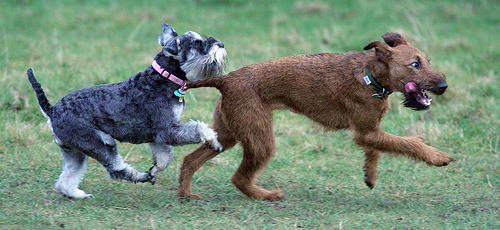

In [ ]:
import random

# 1. Pick a random image index from your dataset
random_idx = random.randint(0, len(dataset) - 1)
img_name = dataset.df.iloc[random_idx]['image']
img_path = os.path.join(image_folder, img_name)

# 2. Find all 5 human-written captions for this image to calculate the BLEU score
actual_captions = dataset.df[dataset.df['image'] == img_name]['caption'].tolist()

# 3. Call the function from Cell 7 to see the results
print(f"--- Evaluation for Image: {img_name} ---")
generate_and_evaluate(img_path, actual_captions)

# 4. Optional: Display the image so you can see if the caption makes sense
from IPython.display import Image as DisplayImage, display
display(DisplayImage(img_path))